# Lab 4: Model-Based Offline Optimization

In this lab, we explore **Model-Based Offline Optimization (MBO)**, a method to optimize black-box functions using only a pre-collected dataset, without additional function evaluations. We'll use two functions from the **Black-Box Optimization Benchmarking (BBOB)** suite:
- **f1** [Sphere Function](https://numbbo.github.io/gforge/downloads/download16.00/bbobdocfunctions.pdf#page=5): A simple, unimodal function with a global minimum at (0, 0).
- **f22** [Gallagher's Gaussian 21-hi Peaks Function](https://numbbo.github.io/gforge/downloads/download16.00/bbobdocfunctions.pdf#page=110): A complex, multimodal function with many local optima.

Visualizations of these problems are available [here](https://coco-platform.org/testsuites/bbob/viz.html?col=3&dim=2&fun=1&ins=1&typ=all).

### Objectives
1. **Dataset:** Use pre-collected datasets (100k samples each) for f1 and f22, generated via **Latin Hypercube Sampling (LHS)** [learn more about LHS here](https://en.wikipedia.org/wiki/Latin_hypercube_sampling).
2. **Surrogate Model:** Train a Multi-Layer Perceptron (MLP) to approximate these functions.
3. **Visualization:** Compare the MLP's predictions to the true functions using contour and scatter plots.
4. **Optimization:** Implement gradient-based optimization on the MLP to find optimal points.
5. **Experiments:** Investigate how training dataset size and model complexity affect performance.

### Key Concepts
- **Offline Optimization:** No new evaluations of the true function are allowed; we rely solely on the dataset.
- **Surrogate Model:** The MLP acts as a cheap, differentiable proxy for the expensive black-box function.
- **Gradient-Based Optimization:** Use the MLP's gradients to find optimal designs efficiently.

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)
print(f'{device=}')

device=device(type='cuda')


### 1. Data Preparation

We start by loading and splitting the dataset into training, validation, and test sets.

In [4]:
def prepare_dataloaders(
    file_path: str,
    batch_size: int = 256,
    train_perc: float = 0.6,
    val_perc: float = 0.2,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """
    Prepare train, validation and test dataloaders.

    Args:
        file_path: Path to CSV data file
        batch_size: Batch size for dataloaders
        train_perc: Percentage of data for training
        val_perc: Percentage of data for validation
    """
    # Load data
    data_df = pd.read_csv(file_path)
    X = torch.tensor(data_df[["x1", "x2"]].values, dtype=torch.float32)
    y = torch.tensor(data_df["y"].values.reshape(-1, 1), dtype=torch.float32)

    # Split data
    num_samples = len(X)
    indices = np.random.permutation(num_samples)
    train_size = int(train_perc * num_samples)
    val_size = int(val_perc * num_samples)

    # Create datasets
    train_dataset = TensorDataset(X[indices[:train_size]], y[indices[:train_size]])
    val_dataset = TensorDataset(
        X[indices[train_size : train_size + val_size]],
        y[indices[train_size : train_size + val_size]],
    )
    test_dataset = TensorDataset(
        X[indices[train_size + val_size :]], y[indices[train_size + val_size :]]
    )

    # Create dataloaders
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

    return train_dataloader, val_dataloader, test_dataloader

# Example usage (replace with your file path)
train_dataloader, val_dataloader, test_dataloader = prepare_dataloaders(
    "./bbob_f022_i01_d02_samples.csv", train_perc=0.3, val_perc=0.4
)

### 2. Define the MLP Model

The MLP will serve as our surrogate model to approximate the black-box function.

In [5]:
class MLP(nn.Module):
    def __init__(
        self, input_dim: int = 2, hidden_dim: int = 256, n_layers: int = 3
    ) -> None:
        """
        Multi-Layer Perceptron (MLP) for function approximation.

        Args:
            input_dim (int): Number of input features (e.g., 2 for x1, x2).
            hidden_dim (int): Number of neurons in each hidden layer.
            n_layers (int): Total number of layers (input + hidden + output).
        """
        super(MLP, self).__init__()

        layers = []
        # Input layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())

        # Hidden layers
        for _ in range(n_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())

        # Output layer -> 1 output neuron (regression, single-objective problem)
        layers.append(nn.Linear(hidden_dim, 1))

        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

### 3. Training the Model

We train the MLP using the Adam optimizer and Mean Squared Error (MSE) loss.

In [6]:
model = MLP().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for inputs, targets in train_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    train_loss = train_loss / len(train_dataloader.dataset)
    train_losses.append(train_loss)
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
    val_loss = val_loss / len(val_dataloader.dataset)
    val_losses.append(val_loss)
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}"
        )

model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_loss += loss.item() * inputs.size(0)

test_loss = test_loss / len(test_dataloader.dataset)
print(f"Test Loss: {test_loss:.4f}")

Epoch 10/100, Train Loss: 473.2057, Val Loss: 443.9464
Epoch 20/100, Train Loss: 296.7679, Val Loss: 293.3679
Epoch 30/100, Train Loss: 235.3329, Val Loss: 235.2994
Epoch 40/100, Train Loss: 199.7178, Val Loss: 207.2583
Epoch 50/100, Train Loss: 174.4679, Val Loss: 179.6096
Epoch 60/100, Train Loss: 159.1816, Val Loss: 162.6876
Epoch 70/100, Train Loss: 149.8966, Val Loss: 147.4992
Epoch 80/100, Train Loss: 141.5383, Val Loss: 143.7891
Epoch 90/100, Train Loss: 133.5370, Val Loss: 138.1930
Epoch 100/100, Train Loss: 128.4069, Val Loss: 138.3069
Test Loss: 139.6801


### 4. Visualization

Let's visualize how well the MLP approximates the true function.

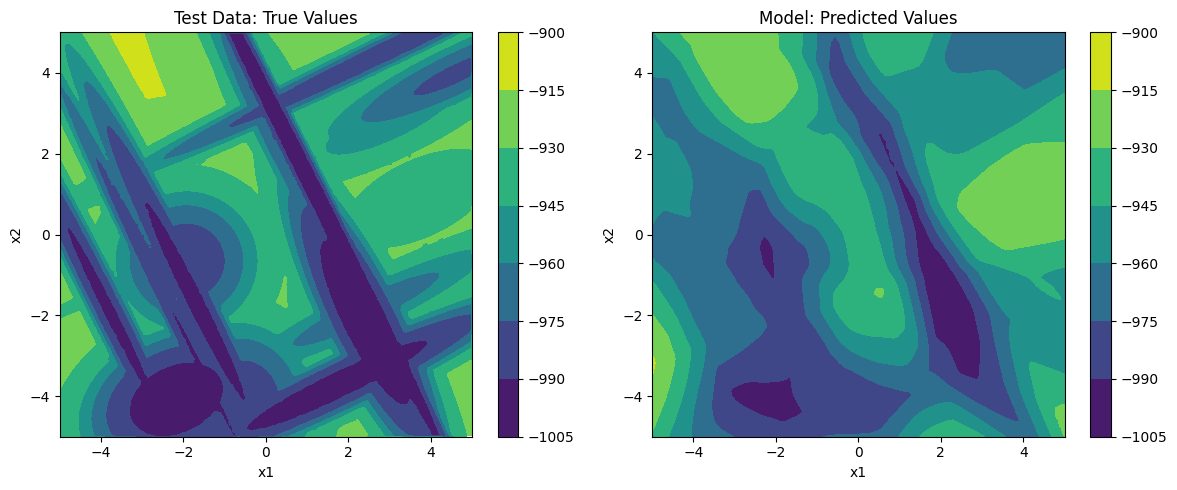

In [7]:
def plot_contour_comparison(
    model: nn.Module, test_dataloader: DataLoader, device: torch.device, best_x_values: list = None
) -> None:
    test_inputs_list = []
    test_targets_list = []

    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        test_inputs_list.append(inputs.cpu().numpy())
        test_targets_list.append(targets.cpu().numpy())

    test_inputs = np.vstack(test_inputs_list)
    test_targets = np.concatenate(test_targets_list)

    x1_min, x1_max = test_inputs[:, 0].min(), test_inputs[:, 0].max()
    x2_min, x2_max = test_inputs[:, 1].min(), test_inputs[:, 1].max()
    x1_vals = np.linspace(x1_min, x1_max, 100)
    x2_vals = np.linspace(x2_min, x2_max, 100)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    grid_points = np.column_stack((X1.flatten(), X2.flatten()))
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        predictions = model(grid_tensor).cpu().numpy().flatten()

    Z_pred = predictions.reshape(X1.shape)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    true_contour = ax1.tricontourf(
        test_inputs[:, 0], test_inputs[:, 1], test_targets.reshape(-1)
    )
    ax1.set_title("Test Data: True Values")
    ax1.set_xlabel("x1")
    ax1.set_ylabel("x2")
    plt.colorbar(true_contour, ax=ax1)

    pred_contour = ax2.contourf(X1, X2, Z_pred)
    ax2.set_title("Model: Predicted Values")
    ax2.set_xlabel("x1")
    ax2.set_ylabel("x2")
    plt.colorbar(pred_contour, ax=ax2)

    if best_x_values is not None:
        best_x_array = np.vstack(best_x_values)

        ax1.scatter(
            best_x_array[:, 0],
            best_x_array[:, 1],
            c="red",
            marker="x",
            label="Optima"
        )
        ax1.legend()

        ax2.scatter(
            best_x_array[:, 0],
            best_x_array[:, 1],
            c="red",
            marker="x",
            label="Optima"
        )
        ax2.legend()

    plt.tight_layout()
    plt.show()



plot_contour_comparison(model, test_dataloader, device)

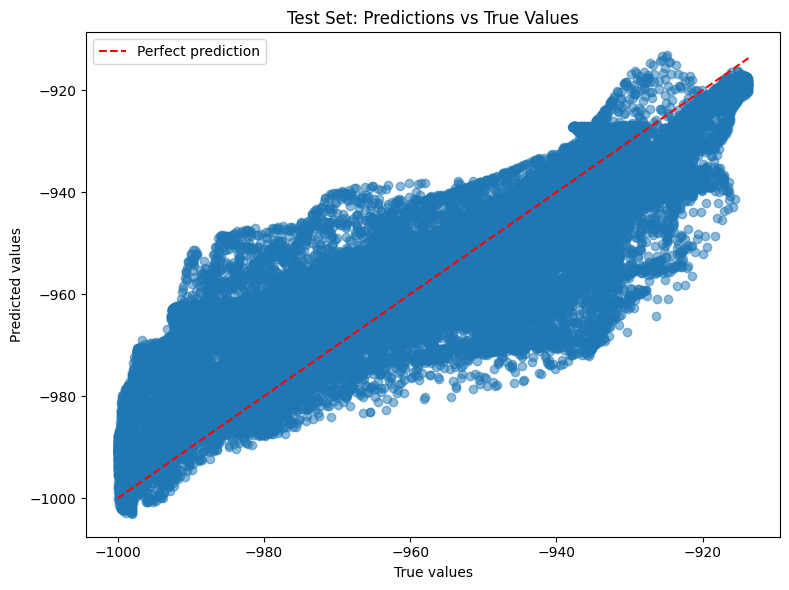

In [8]:
def plot_prediction_scatter(
    model: nn.Module, test_dataloader: DataLoader, device: torch.device
) -> None:
    test_targets_list = []
    test_preds_list = []

    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        with torch.no_grad():
            outputs = model(inputs)

        test_targets_list.append(targets.cpu().numpy())
        test_preds_list.append(outputs.cpu().numpy())

    test_targets = np.concatenate(test_targets_list)
    test_preds = np.concatenate(test_preds_list).flatten()

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(test_targets, test_preds, alpha=0.5)
    ax.plot(
        [test_targets.min(), test_targets.max()],
        [test_targets.min(), test_targets.max()],
        "r--",
        label="Perfect prediction",
    )
    ax.set_xlabel("True values")
    ax.set_ylabel("Predicted values")
    ax.set_title("Test Set: Predictions vs True Values")
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_prediction_scatter(model, test_dataloader, device)

### 5. Gradient-Based Optimization

Now, we optimize the trained MLP to find the input that minimizes its output (our surrogate's prediction).

In [10]:
def optimize_model(
    model: nn.Module, num_steps: int = 1000
) -> tuple[torch.Tensor, float]:
    """
    Perform gradient-based optimization on the MLP.

    Args:
        model (nn.Module): Trained MLP model.
        num_steps (int): Number of optimization steps.

    Returns:
        tuple: (best_x, best_y) - Optimal input and its predicted output.
    """
    model.eval()
    # Select random starting point in [-5, 5]^2
    x = torch.rand(1, 2, device=device) * 10 - 5
    x.requires_grad_(True)
    optimizer =  torch.optim.Adam([x], lr=0.01)

    best_x = x.clone().detach()
    best_y = float("inf")

    for _ in range(num_steps):
        optimizer.zero_grad()
        # Predict output (our output - result of the model is the function we want to minimize)
        # Compute gradients (gradients of our model)
        # Update x
        # Enforce domain constraints [-5, 5]
        outputs = model(x)
        loss = outputs.mean()

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            x.clamp_(-5, 5)

        if loss.item() < best_y:
            best_y = loss.item()
            best_x = x.clone().detach()

    return best_x, best_y

### Exercise 1: Impact of Dataset Size
- **Task:** Train the MLP with different training set sizes (e.g., 100, 1000, 5000, 10000, 50000).
- **Instructions:**
  1. Modify the `train_perc` parameter in `prepare_dataloaders` to achieve these different dataset sizes (keep the test set size fixed at approximately 30,000 samples).
  2. Train the model for each dataset size and generate corresponding contour plots.
  3. Analyze how the MLP's ability to capture the underlying function structure (particularly the multimodal nature of f22) improves with increasing data volume.
  4. Select and justify a single quantitative metric that effectively captures the model’s predictive quality in this context. Use this metric to evaluate model performance across different training set sizes. Present the results as a plot to visualize how model quality scales with data availability.



---------Train dataset size: 100---------
Epoch 10/100, Train Loss: 907187.5625, Val Loss: 904355.0644
Epoch 20/100, Train Loss: 879445.1250, Val Loss: 876394.4986
Epoch 30/100, Train Loss: 836312.4375, Val Loss: 833405.1225
Epoch 40/100, Train Loss: 774504.3750, Val Loss: 772339.0190
Epoch 50/100, Train Loss: 692101.2500, Val Loss: 691580.1303
Epoch 60/100, Train Loss: 590238.2500, Val Loss: 592448.9258
Epoch 70/100, Train Loss: 474237.0312, Val Loss: 480172.1293
Epoch 80/100, Train Loss: 354222.0312, Val Loss: 364358.8306
Epoch 90/100, Train Loss: 244400.0781, Val Loss: 258233.8305
Epoch 100/100, Train Loss: 159575.5938, Val Loss: 175345.3893
Test Loss: 175820.5104


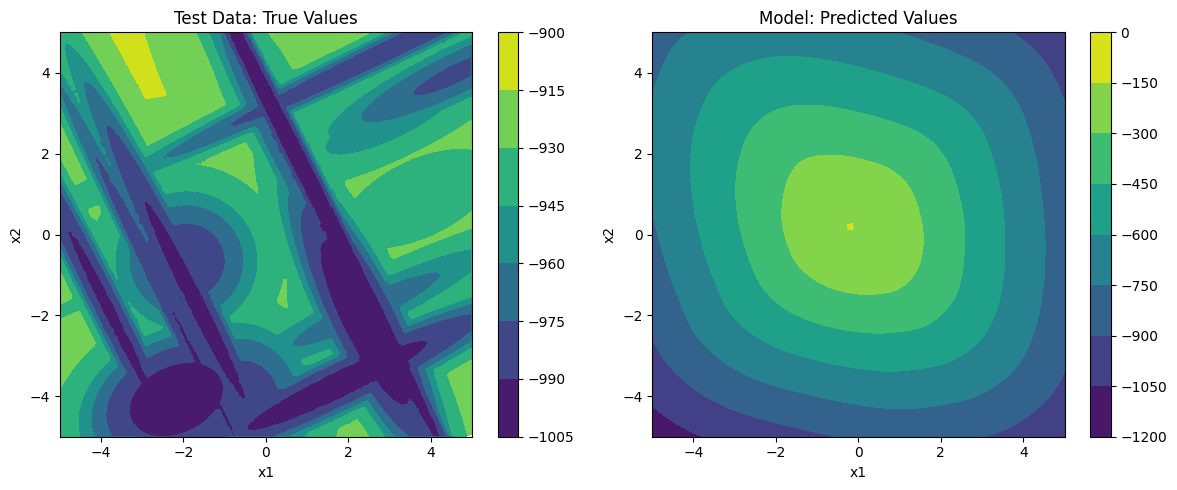

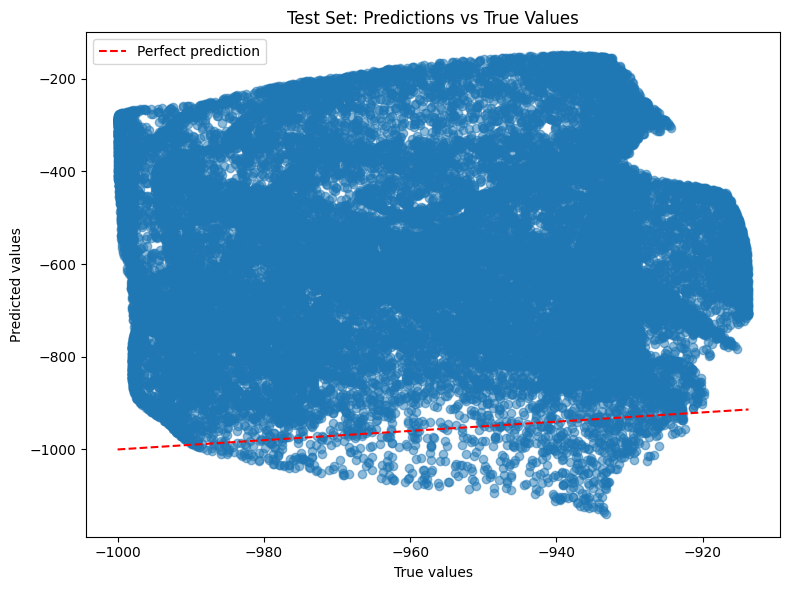

---------Train dataset size: 1000---------
Epoch 10/100, Train Loss: 785181.3340, Val Loss: 767908.5695
Epoch 20/100, Train Loss: 389329.5893, Val Loss: 364370.3246
Epoch 30/100, Train Loss: 96708.0867, Val Loss: 94152.3994
Epoch 40/100, Train Loss: 81248.8837, Val Loss: 82634.9691
Epoch 50/100, Train Loss: 77295.9939, Val Loss: 78984.6909
Epoch 60/100, Train Loss: 73306.0772, Val Loss: 74895.0887
Epoch 70/100, Train Loss: 69067.8826, Val Loss: 70587.1270
Epoch 80/100, Train Loss: 64564.2097, Val Loss: 66008.8324
Epoch 90/100, Train Loss: 59726.7458, Val Loss: 61055.7212
Epoch 100/100, Train Loss: 54540.2638, Val Loss: 55816.8707
Test Loss: 55782.3633


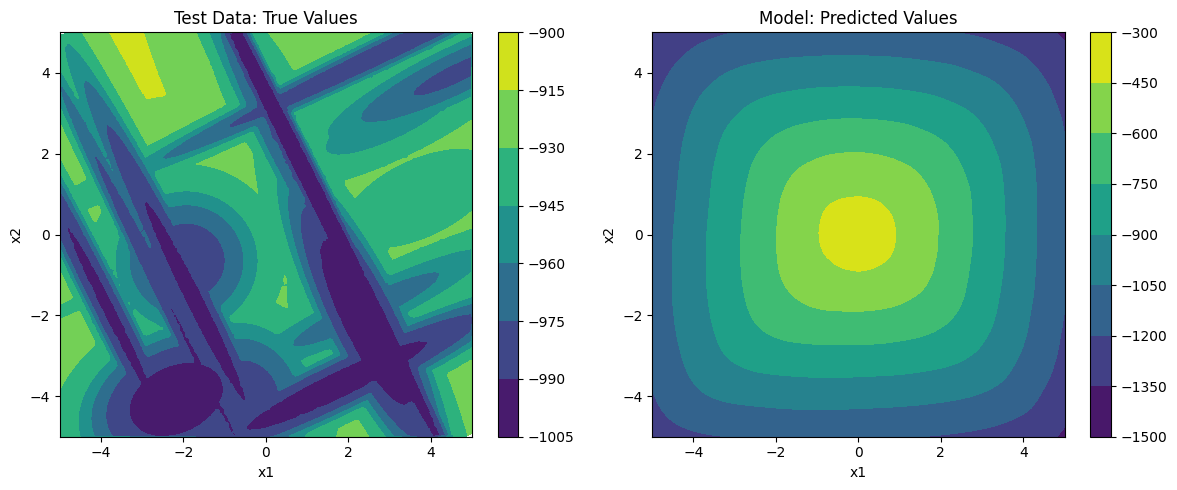

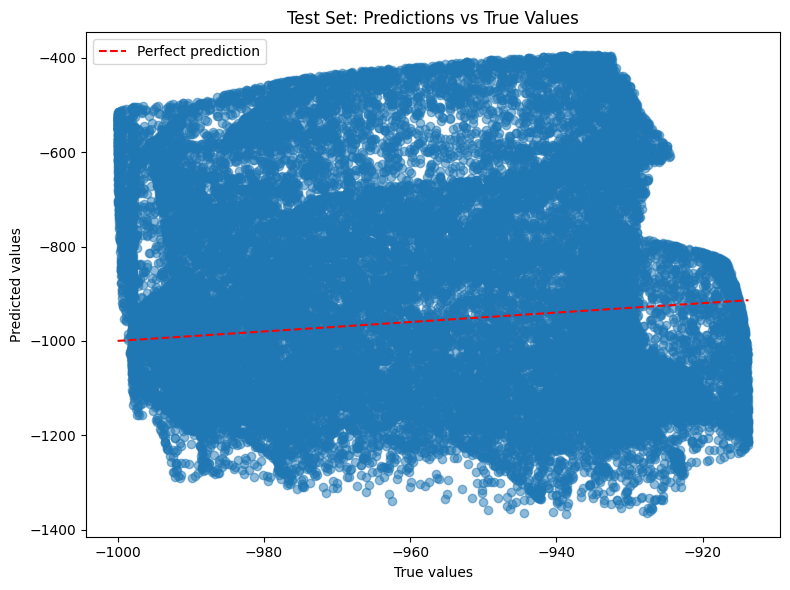

---------Train dataset size: 5000---------
Epoch 10/100, Train Loss: 76038.5604, Val Loss: 74847.6355
Epoch 20/100, Train Loss: 51648.5468, Val Loss: 50102.6010
Epoch 30/100, Train Loss: 22847.0019, Val Loss: 21402.1547
Epoch 40/100, Train Loss: 4593.1499, Val Loss: 4119.2666
Epoch 50/100, Train Loss: 823.4106, Val Loss: 786.4353
Epoch 60/100, Train Loss: 563.4481, Val Loss: 561.2283
Epoch 70/100, Train Loss: 511.5416, Val Loss: 511.7191
Epoch 80/100, Train Loss: 478.5628, Val Loss: 479.1808
Epoch 90/100, Train Loss: 450.3814, Val Loss: 449.8292
Epoch 100/100, Train Loss: 427.1840, Val Loss: 426.4362
Test Loss: 427.3735


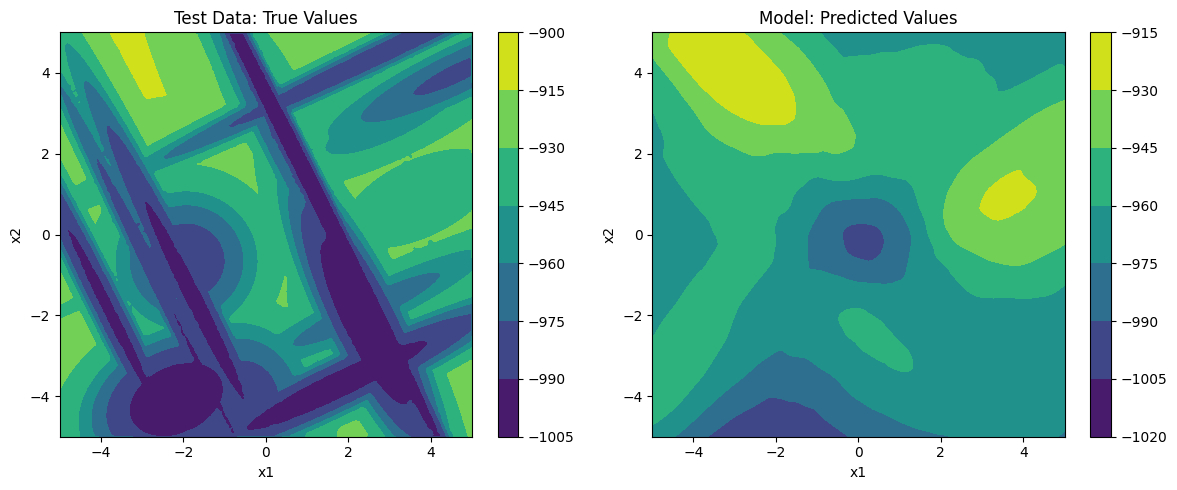

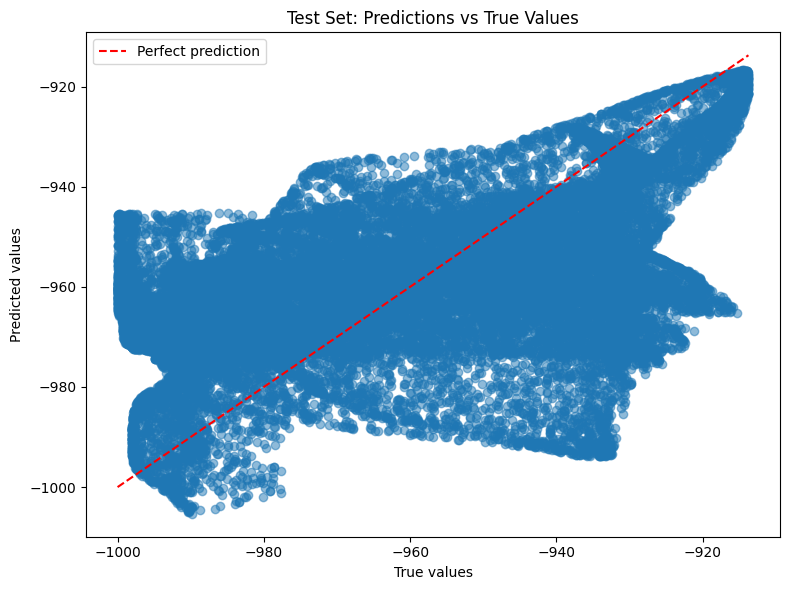

---------Train dataset size: 10000---------
Epoch 10/100, Train Loss: 60978.3693, Val Loss: 59332.5728
Epoch 20/100, Train Loss: 10677.8208, Val Loss: 9117.0403
Epoch 30/100, Train Loss: 596.0936, Val Loss: 579.4048
Epoch 40/100, Train Loss: 482.6028, Val Loss: 483.0914
Epoch 50/100, Train Loss: 442.6364, Val Loss: 445.4896
Epoch 60/100, Train Loss: 410.6633, Val Loss: 412.2483
Epoch 70/100, Train Loss: 381.4528, Val Loss: 382.8419
Epoch 80/100, Train Loss: 349.9501, Val Loss: 350.6699
Epoch 90/100, Train Loss: 321.1541, Val Loss: 322.4342
Epoch 100/100, Train Loss: 301.8803, Val Loss: 299.3487
Test Loss: 297.2802


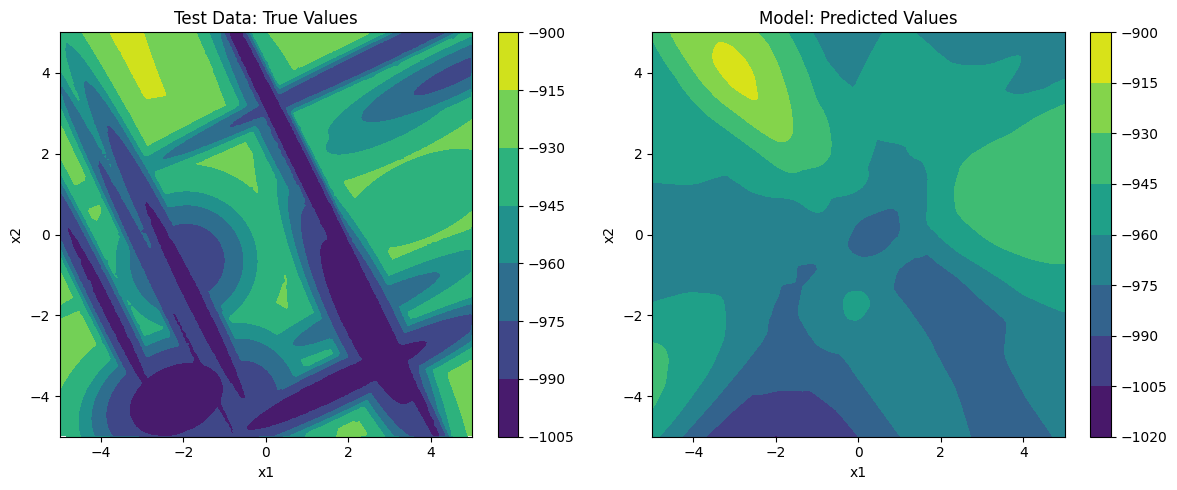

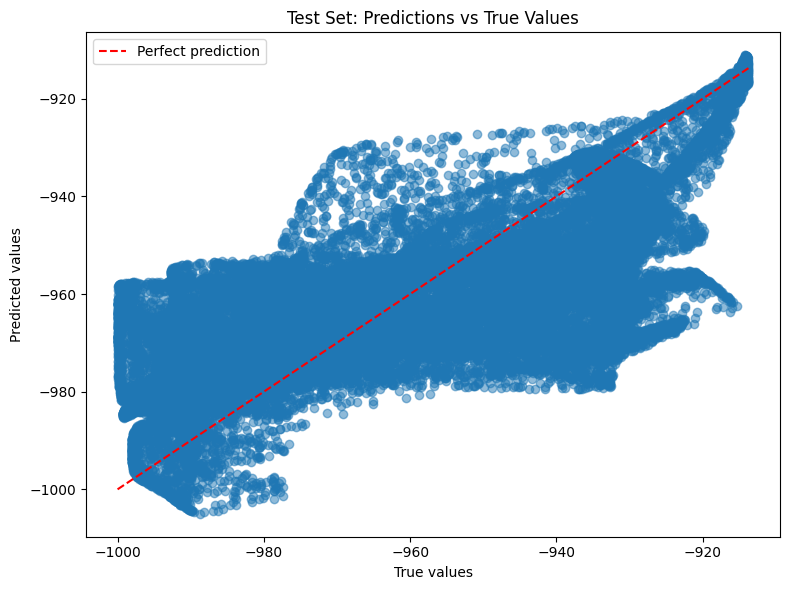

---------Train dataset size: 50000---------
Epoch 10/100, Train Loss: 460.4490, Val Loss: 452.4036
Epoch 20/100, Train Loss: 324.4710, Val Loss: 319.6038
Epoch 30/100, Train Loss: 215.7128, Val Loss: 213.1666
Epoch 40/100, Train Loss: 163.3292, Val Loss: 166.1163
Epoch 50/100, Train Loss: 139.0322, Val Loss: 136.8792
Epoch 60/100, Train Loss: 123.9541, Val Loss: 122.8162
Epoch 70/100, Train Loss: 112.9719, Val Loss: 120.7455
Epoch 80/100, Train Loss: 107.9730, Val Loss: 131.5293
Epoch 90/100, Train Loss: 101.6181, Val Loss: 99.6552
Epoch 100/100, Train Loss: 97.5894, Val Loss: 100.7821
Test Loss: 99.1681


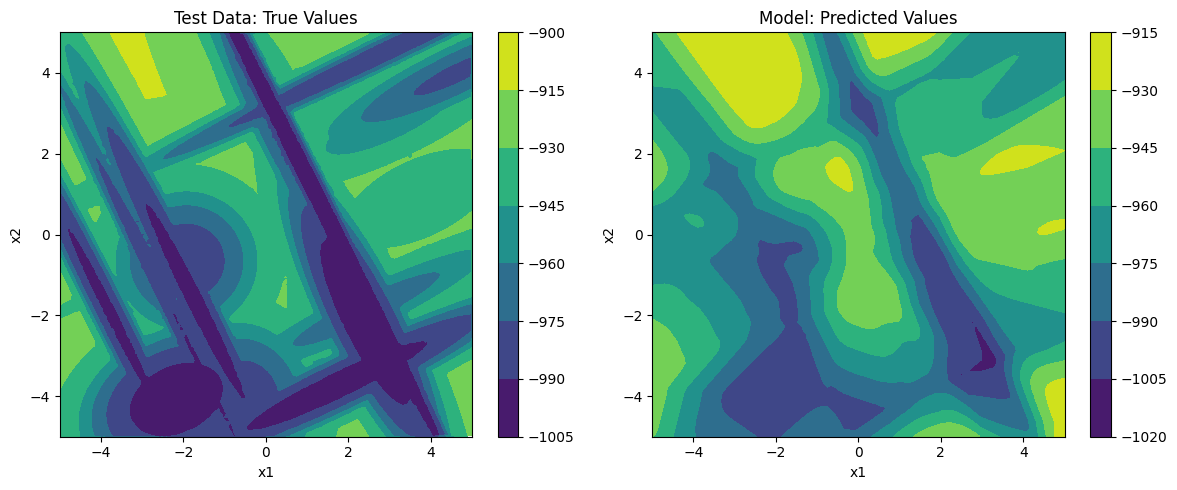

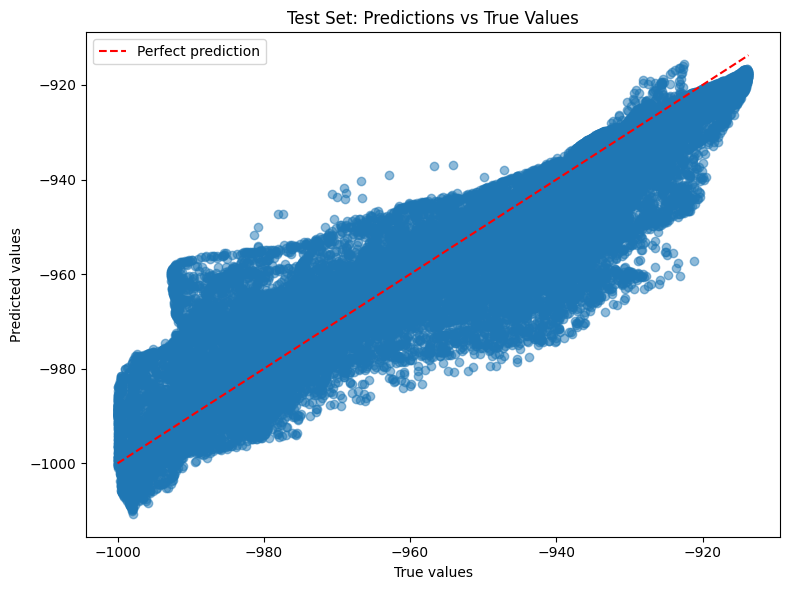

In [14]:
train_sizes = [100,1000, 5000, 10000, 50000]
samples_count = 100_000

rmse_to_train_size = []
for train_size in train_sizes:

    print(f'---------Train dataset size: {train_size}---------')

    train_dataloader, val_dataloader, test_dataloader = prepare_dataloaders(
        "./bbob_f022_i01_d02_samples.csv", train_perc=train_size/samples_count, val_perc=0.7-train_size/samples_count
    )

    model = MLP().to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    num_epochs = 100

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        for inputs, targets in train_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)

        train_loss = train_loss / len(train_dataloader.dataset)
        train_losses.append(train_loss)
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_dataloader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
        val_loss = val_loss / len(val_dataloader.dataset)
        val_losses.append(val_loss)
        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}"
            )

    model.eval()
    test_loss = 0.0
    mse_sum = 0.0
    n_samples = 0
    with torch.no_grad():
        for inputs, targets in test_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item() * inputs.size(0)
            mse_sum += ((outputs - targets) ** 2).sum().item()
            n_samples += targets.size(0)
    rmse = (mse_sum / n_samples) ** 0.5
    rmse_to_train_size.append(rmse)

    test_loss = test_loss / len(test_dataloader.dataset)
    print(f"Test Loss: {test_loss:.4f}")
    plot_contour_comparison(model, test_dataloader, device)
    plot_prediction_scatter(model, test_dataloader, device)

[419.30956396597173, 236.18290212072225, 20.673014584599862, 17.24181648992924, 9.958319042844641]


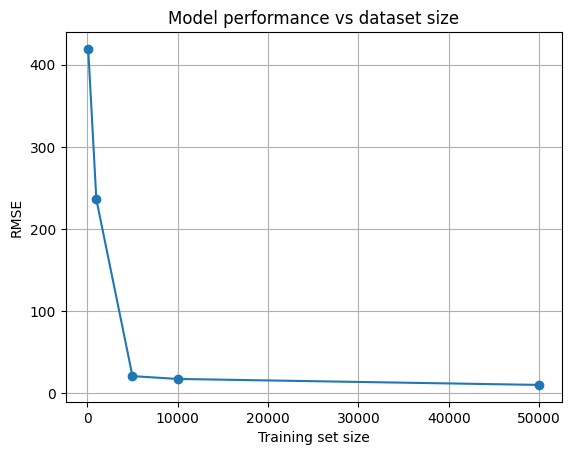

In [16]:
print(rmse_to_train_size)
plt.plot(train_sizes, rmse_to_train_size, marker='o')
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.title("Model performance vs dataset size")
plt.grid()
plt.show()

### Exercise 2: Optimization Robustness
- **Task:** Implement the `optimize_model` function to find inputs that minimize the model's output.
- **Instructions:**
  1. Execute the optimization process multiple times (e.g. 10 for each dataset) with different random starting points and record the best surrogate values.
  2. Create a histogram of the best `y` values across all optimization runs to visualize the distribution of results.
  3. Generate a contour plot showing the locations of the solutions found. Analyze the consistency of these solutions.
  4. Use `cocoex` to evaluate the true objective function at the solution points. Compare these values against the surrogate’s predicted values.


Dataset: bbob_f022_i01_d02_samples.csv
Test Loss: 152.9481


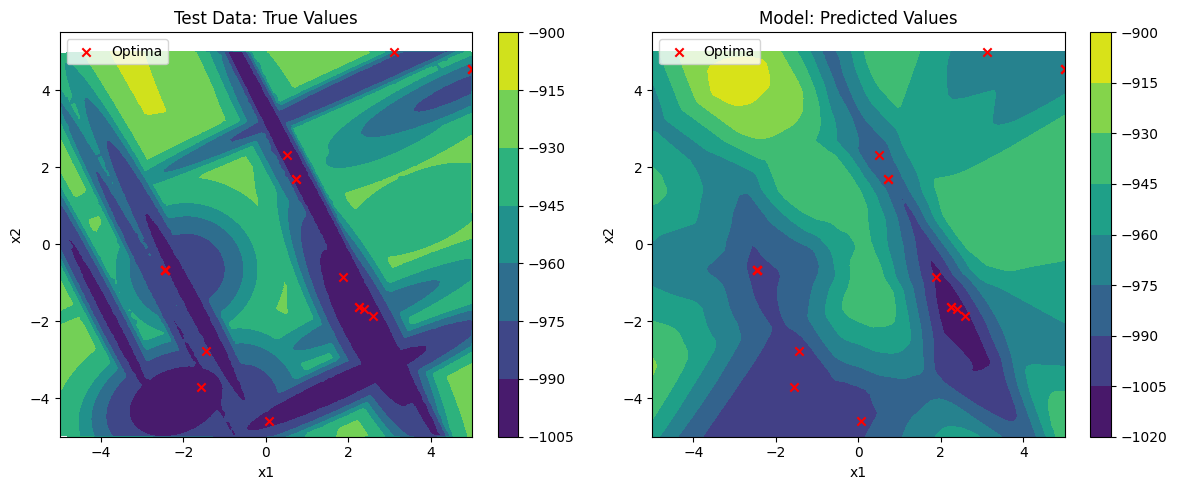


Dataset: bbob_f001_i01_d02_samples.csv
Test Loss: 0.0063


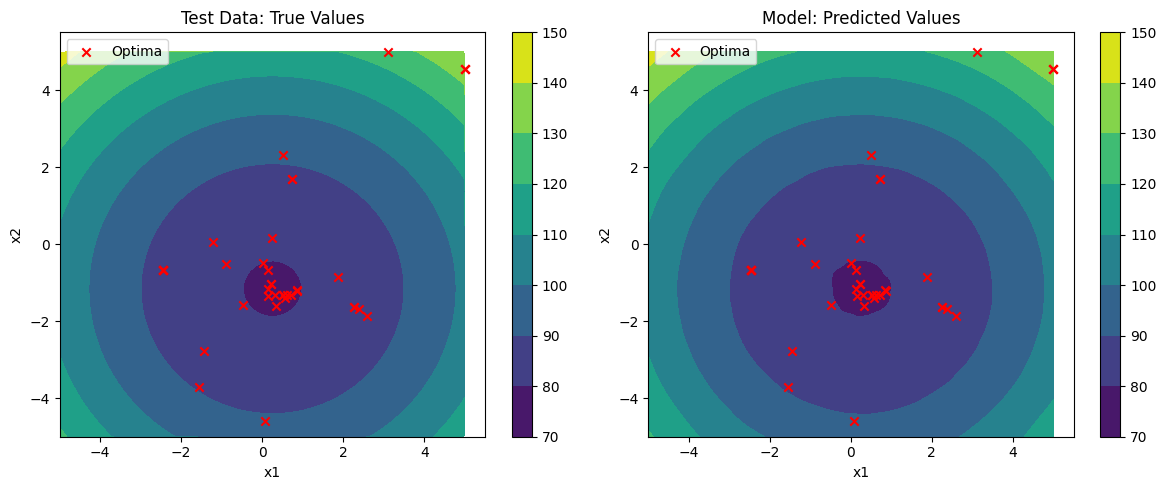

In [13]:
best_x_values = []
best_y_values = []

dataset_paths = [
    "bbob_f022_i01_d02_samples.csv",
    "bbob_f001_i01_d02_samples.csv"
]

for path in dataset_paths:

    train_dataloader, val_dataloader, test_dataloader = prepare_dataloaders(
        path, train_perc=0.3, val_perc=0.4
    )

    model = MLP().to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(100):
        model.train()
        for inputs, targets in train_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for inputs, targets in test_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item() * inputs.size(0)

    test_loss /= len(test_dataloader.dataset)
    print(f"\nDataset: {path}")
    print(f"Test Loss: {test_loss:.4f}")

    for _ in range(20):
        best_x, best_y = optimize_model(model, num_steps=500)
        best_x_values.append(best_x.cpu().numpy())
        best_y_values.append(best_y)

    plot_contour_comparison(model, test_dataloader, device, best_x_values)

best_y_values=[-1012.1940307617188, -988.0472412109375, -972.428955078125, -1011.2101440429688, -1012.1981201171875, -997.1090087890625, -1008.2674560546875, -1001.5845947265625, -997.10595703125, -972.428955078125, -1011.8663330078125, -997.1083374023438, -989.0592651367188, -989.0595703125, -972.8525390625, -972.428955078125, -994.08349609375, -1000.9751586914062, -997.1094360351562, -997.1102905273438, 79.5279541015625, 83.16329956054688, 79.78436279296875, 79.4808578491211, 79.62737274169922, 81.1851577758789, 79.5036392211914, 79.48082733154297, 79.77534484863281, 80.20415496826172, 79.64546203613281, 79.3900146484375, 79.9422836303711, 81.19074249267578, 79.47911071777344, 79.48135375976562, 79.3900146484375, 79.5235824584961, 79.67671966552734, 79.42581176757812]


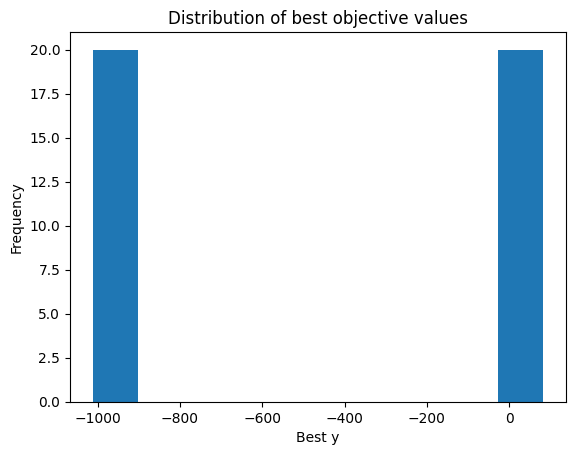

In [17]:
print(f'{best_y_values=}')
plt.hist(best_y_values, bins=10)
plt.xlabel("Best y")
plt.ylabel("Frequency")
plt.title("Distribution of best objective values")
plt.show()

### Accessing Original COCO Benchmark Problems

The code below installs and imports the necessary packages to access the original COCO benchmark problems (f1 and f22).
This will allow us to compare our model's predictions with the true functions and evaluate optimization performance.

In [ ]:
! pip install coco-experiment cocopp

bbob_f022_i01_d02: a 2-dimensional single-objective problem (problem 315 of suite "b'bbob'" with name "BBOB suite problem f22 instance 1 in 2D")
Function value at (0, 0): -936.0557554469844

Surrogate vs True:
0: pred=-1012.1940, true=-998.3603
1: pred=-988.0472, true=-999.6994
2: pred=-972.4290, true=-970.6925
3: pred=-1011.2101, true=-999.5285
4: pred=-1012.1981, true=-998.3461
5: pred=-997.1090, true=-987.2002
6: pred=-1008.2675, true=-995.8717
7: pred=-1001.5846, true=-995.5888
8: pred=-997.1060, true=-987.2549
9: pred=-972.4290, true=-970.6921
10: pred=-1011.8663, true=-998.0178
11: pred=-997.1083, true=-987.3987
12: pred=-989.0593, true=-997.9936
13: pred=-989.0596, true=-997.9909
14: pred=-972.8525, true=-962.1973
15: pred=-972.4290, true=-970.6913
16: pred=-994.0835, true=-992.3741
17: pred=-1000.9752, true=-986.0594
18: pred=-997.1094, true=-987.2323
19: pred=-997.1103, true=-987.3796
20: pred=79.5280, true=-931.5475
21: pred=83.1633, true=-973.6879
22: pred=79.7844, true=-944

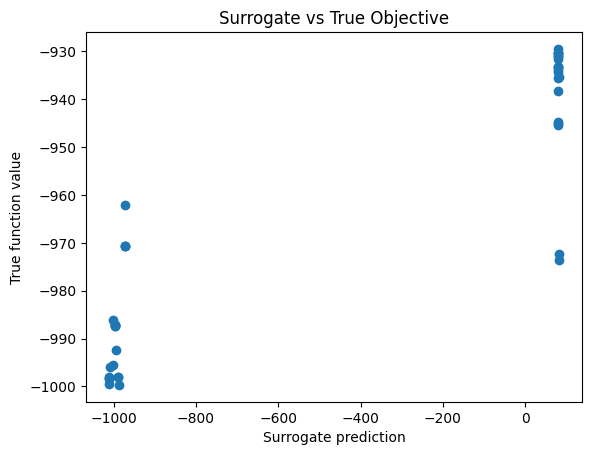

In [18]:
from cocoex import Suite

function_id = 22  # Switch between 1 and 22 to change the function

suite = Suite(
    "bbob",
    "",
    f"function_indices: {function_id}, dimensions: 2 instance_indices: 1",
)
for function in suite:
    print(function.info)
    print("Function value at (0, 0):", function(np.array([0, 0])))

    true_values = []
    for x in best_x_values:
        val = function(x.flatten())
        true_values.append(val)


    print("\nSurrogate vs True:")
    for i in range(len(best_y_values)):
        print(f"{i}: pred={best_y_values[i]:.4f}, true={true_values[i]:.4f}")


    plt.scatter(best_y_values, true_values)
    plt.xlabel("Surrogate prediction")
    plt.ylabel("True function value")
    plt.title("Surrogate vs True Objective")
    plt.show()